In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import shapiro, probplot, f_oneway, chisquare
from scipy import stats

## 8 One-way ANOVA, or Kruskal-Wallis Test

Hypothesis Formulation for One-Way ANOVA

We are comparing the mean number of weekly website visits (in thousands) across three national websites: Sweden, Denmark, and Norway.

Null Hypothesis (H₀):
There is no significant difference in the mean number of weekly website visits among the three websites.

Mathematically:

$$
H_0: \mu_{\text{Sweden}} = \mu_{\text{Denmark}} = \mu_{\text{Norway}}
$$

Alternative Hypothesis (Hₐ):
At least one of the website means is significantly different from the others.

Mathematically:

$$
H_a: \text{At least one } \mu_i \text{ is different}
$$

In [2]:
webcount = pd.read_csv(r'data/webcount.csv', sep=';')
print(webcount)

   websiteSWE  websiteDEN  websiteNOR
0        18.2        17.4        15.2
1        20.1        18.7        18.8
2        17.6        19.1        17.7
3        16.8        16.4        16.5
4        18.8        15.9        15.9
5        19.7        18.4        17.1
6        19.1        17.7        16.7


In [261]:
type(webcount)

pandas.core.frame.DataFrame

In [262]:
webcount.describe()

,websiteSWE,websiteDEN,websiteNOR
count,7.000000,7.000000,7.000000
mean,18.614286,17.657143,16.842857
std,1.165373,1.187234,1.180194
min,16.800000,15.900000,15.200000
25%,17.900000,16.900000,16.200000
50%,18.800000,17.700000,16.700000
75%,19.400000,18.550000,17.400000
max,20.100000,19.100000,18.800000


In [263]:
def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), stats.sem(a)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return m-h, m+h

In [264]:
print(webcount[webcount.columns[2]])
swe = webcount[webcount.columns[0]]
den = webcount[webcount.columns[1]]
nor = webcount[webcount.columns[2]]

0    15.2
1    18.8
2    17.7
3    16.5
4    15.9
5    17.1
6    16.7
Name: websiteNOR, dtype: float64


In [265]:
for column in webcount.columns:
    lower, upper = mean_confidence_interval(webcount[column])
    print(f"{column}:\n 95% CI = ({lower:.2f}, {upper:.2f})\n")

websiteSWE:
 95% CI = (17.54, 19.69)

websiteDEN:
 95% CI = (16.56, 18.76)

websiteNOR:
 95% CI = (15.75, 17.93)



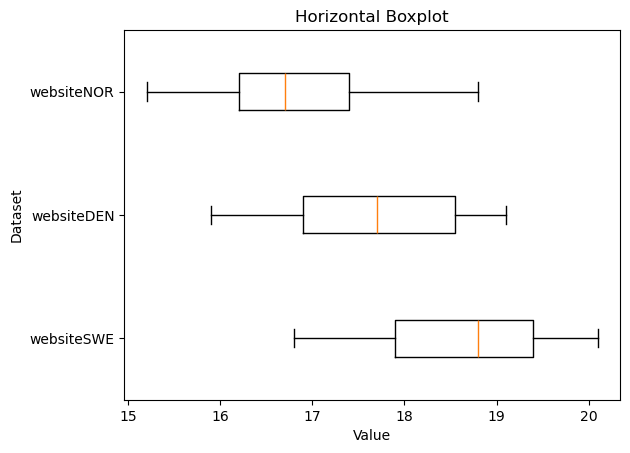

In [266]:
plt.boxplot([swe, den, nor],
            tick_labels=['websiteSWE', 'websiteDEN', 'websiteNOR'], 
            vert=False)
# Plots graph
plt.title('Horizontal Boxplot')
plt.xlabel('Value')
plt.ylabel('Dataset')
plt.show()

### (a) Qualitative Assessment using Box Plots and Histograms

Box plots and histograms help visualize the distribution of each sample:
- Symmetric box plots and bell-shaped histograms suggest normality.
- Skewness or strong outliers indicate potential non-normality.

---

### (b) Qualitative Assessment using Q-Q Plots

Q-Q (quantile-quantile) plots compare the sample quantiles to the theoretical quantiles of a normal distribution:
- If the data points lie approximately along the diagonal line, the data is likely normally distributed.
- Systematic deviations indicate departures from normality.

---

### (c) Quantitative Assessment using the Shapiro-Wilk Test

The Shapiro-Wilk test is a formal test for normality.

- **Null Hypothesis (H₀):** The data is normally distributed.
- **Alternative Hypothesis (Hₐ):** The data is not normally distributed.
- If the p-value > 0.05 → we **fail to reject H₀** → assume normality.
- If the p-value ≤ 0.05 → we **reject H₀** → normality assumption is violated.

---

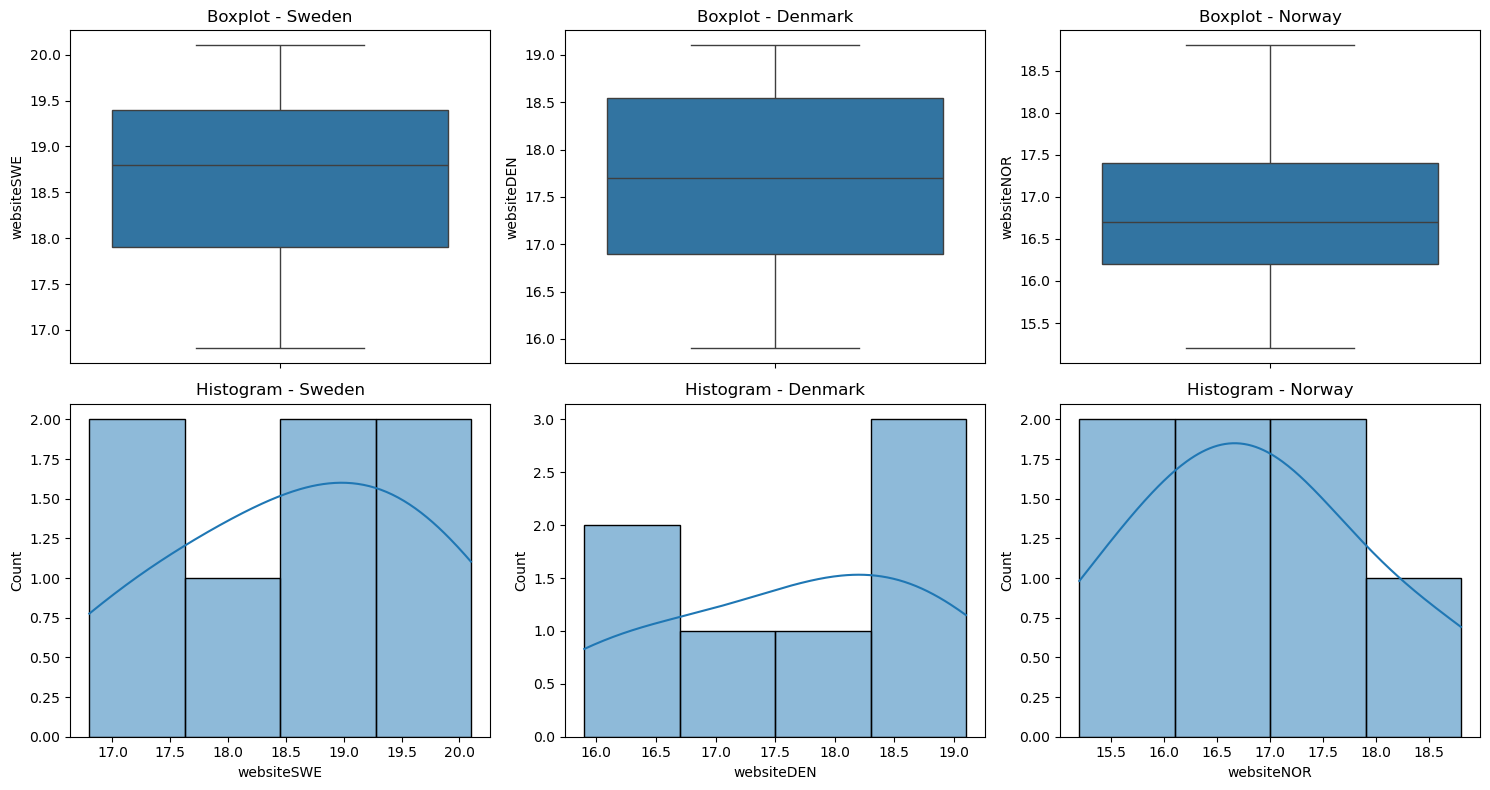

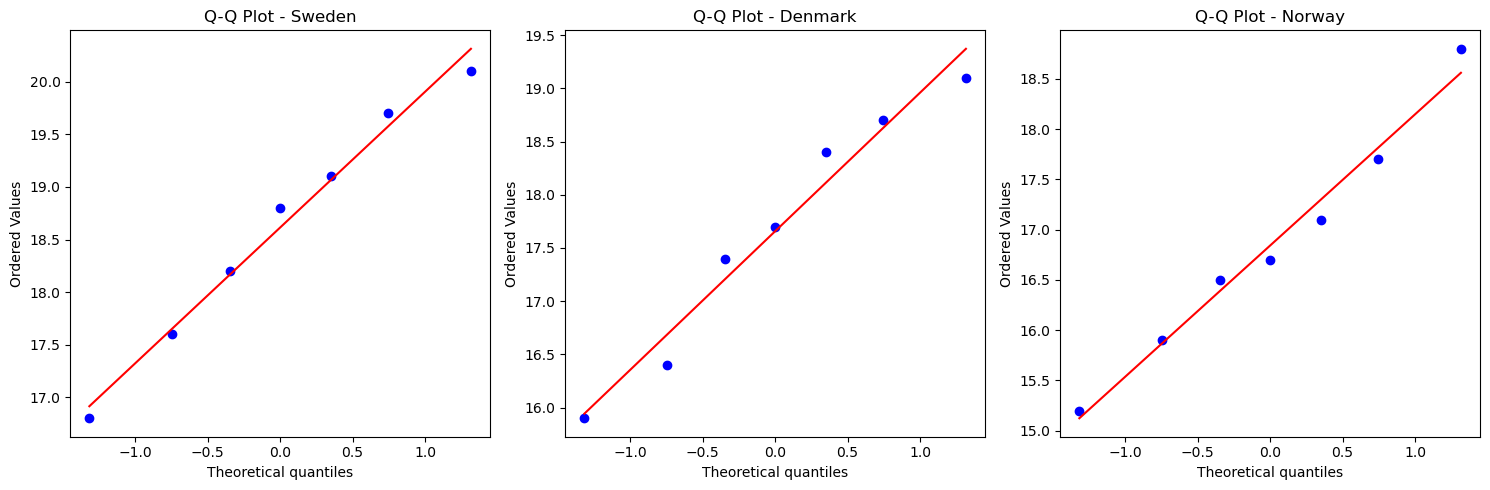

Shapiro-Wilk Normality Test Results:
Sweden: p-value = 0.9359 → ✓ Normal
Denmark: p-value = 0.7146 → ✓ Normal
Norway: p-value = 0.9886 → ✓ Normal


In [268]:
# (a) Boxplots and Histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.boxplot(y=swe, ax=axes[0, 0])
axes[0, 0].set_title('Boxplot - Sweden')
sns.boxplot(y=den, ax=axes[0, 1])
axes[0, 1].set_title('Boxplot - Denmark')
sns.boxplot(y=nor, ax=axes[0, 2])
axes[0, 2].set_title('Boxplot - Norway')

sns.histplot(swe, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Histogram - Sweden')
sns.histplot(den, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Histogram - Denmark')
sns.histplot(nor, kde=True, ax=axes[1, 2])
axes[1, 2].set_title('Histogram - Norway')

plt.tight_layout()
plt.show()

# (b) Q-Q Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
probplot(swe, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot - Sweden")
probplot(den, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot - Denmark")
probplot(nor, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot - Norway")
plt.tight_layout()
plt.show()

# (c) Shapiro-Wilk Tests
print("Shapiro-Wilk Normality Test Results:")
for name, data in zip(["Sweden", "Denmark", "Norway"], [swe, den, nor]):
    stat, p = shapiro(data)
    result = "✓ Normal" if p > 0.05 else "✗ Not Normal"
    print(f"{name}: p-value = {p:.4f} → {result}")

In [269]:
import numpy as np

def detect_outliers(data, label):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"{label}: Found {len(outliers)} outlier(s).")
    if len(outliers):
        print(f"  Values: {outliers.values}")
    else:
        print("  No outliers detected.")
    return outliers

# Run for each country
outliers_swe = detect_outliers(swe, "Sweden")
outliers_den = detect_outliers(den, "Denmark")
outliers_nor = detect_outliers(nor, "Norway")

Sweden: Found 0 outlier(s).
  No outliers detected.
Denmark: Found 0 outlier(s).
  No outliers detected.
Norway: Found 0 outlier(s).
  No outliers detected.


In [270]:
print("Because our data is normal as we can see in the tests that were ran before, we do One-Way ANOVA: ")

anova_result = f_oneway(swe, den, nor)
print(f"ANOVA p-value: {anova_result.pvalue:.4f}")

if anova_result.pvalue < 0.05:
    print("Conclusion: There is a significant difference between the groups.")
else:
    print("Conclusion: There is no significant difference between the groups.")

Because our data is normal as we can see in the tests that were ran before, we do One-Way ANOVA: 
ANOVA p-value: 0.0373
Conclusion: There is a significant difference between the groups.


## Interpreting the ANOVA Result

We performed a one-way ANOVA test to determine whether there are significant differences in the mean number of weekly website visits among the three countries (Sweden, Denmark, and Norway).

### Test Result:
- **ANOVA p-value = 0.0373**

### Decision:
Since the p-value is **less than 0.05**, we **reject the null hypothesis (H₀)**.

### Explanation:
The null hypothesis stated that the mean number of website visits is equal for all three countries:

$$
H_0: \mu_{\text{Sweden}} = \mu_{\text{Denmark}} = \mu_{\text{Norway}}
$$

The p-value of 0.0373 indicates that the probability of observing differences between the group means as large as we did (or larger), **if the true means were actually equal**, is only about **3.7%**. This is low enough to be considered **unlikely** under the null hypothesis.

### Conclusion:
There is statistically significant evidence to suggest that **at least one country's website has a different average number of visits** compared to the others. Therefore, we reject the null hypothesis and conclude that the number of weekly website visits **is not the same** across all three countries.

In [272]:
print("Since ANOVA told us there's a difference somewhere, Tukey’s HSD (Honestly Significant Difference) test will help us pinpoint " 
      "exactly where — that is, which specific groups differ from each other.\n\nWhat is Tukey’s test?\n\nTukey’s test compares all " 
      "possible pairs of group means (e.g., Sweden vs. Denmark, Sweden vs. Norway, Denmark vs. Norway) and determines \nwhether the " 
      "differences between them are statistically significant.\n\n")

# Combine all data into one DataFrame for Tukey's test
data = pd.concat([swe, den, nor], axis=0)
groups = (['Sweden'] * len(swe)) + (['Denmark'] * len(den)) + (['Norway'] * len(nor))

# Run Tukey HSD test
tukey = pairwise_tukeyhsd(endog=data, groups=groups, alpha=0.05)

# Show the summary
print(tukey)

print("\n\nInterpretation:\n\n"
      "If 'reject = False', there is no significant difference.\n"
      "If 'reject = True', there is a statistically significant difference between those two groups.\n\n"
      
      "Example Conclusion:\n\n"
      "- There is no significant difference between Denmark and Norway.\n"
      "- There is no significant difference between Denmark and Sweden.\n"
      "- There is a significant difference between Norway and Sweden.\n\n"
      "This means that the Norwegian website has a significantly different "
      "number of visits compared to the Swedish website, but not compared to \n" 
      "the Danish one. The Danish and Swedish sites do not differ significantly in visit numbers.")

Since ANOVA told us there's a difference somewhere, Tukey’s HSD (Honestly Significant Difference) test will help us pinpoint exactly where — that is, which specific groups differ from each other.

What is Tukey’s test?

Tukey’s test compares all possible pairs of group means (e.g., Sweden vs. Denmark, Sweden vs. Norway, Denmark vs. Norway) and determines 
whether the differences between them are statistically significant.


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
Denmark Norway  -0.8143 0.4167 -2.4208 0.7922  False
Denmark Sweden   0.9571 0.3051 -0.6494 2.5637  False
 Norway Sweden   1.7714 0.0294  0.1649 3.3779   True
----------------------------------------------------


Interpretation:

If 'reject = False', there is no significant difference.
If 'reject = True', there is a statistically significant difference between those two groups.

Example Conclusion:

- There i

## 9 Chi-Square (χ2) Goodness-of-Fit test

## Hypothesis Formulation for Chi-Square Goodness-of-Fit Test

We want to determine whether the observed distribution of personality colors in our sample fits the expected distribution based on population data.

### Null Hypothesis (H₀):
The observed distribution of color personalities (Red, Blue, White, Yellow) **matches the expected distribution** in the population:
- Red = 25%
- Blue = 35%
- White = 20%
- Yellow = 20%

Mathematically:
$$
H_0: P_{\text{Red}} = 0.25,\quad P_{\text{Blue}} = 0.35,\quad P_{\text{White}} = 0.20,\quad P_{\text{Yellow}} = 0.20
$$

### Alternative Hypothesis (Hₐ):
The observed distribution **does not match** the expected population distribution.

$$
H_a: \text{At least one } P_i \text{ differs from the expected proportion}
$$

We will use a Chi-Square Goodness-of-Fit test to evaluate whether the differences between observed and expected frequencies are statistically significant.

### Observed Values

The observed counts from the collected sample (based on 400 respondents) are as follows:


\begin{array}{|c|c|}
\hline
\textbf{Color} & \textbf{Observed Count} \\
\hline
\text{Red} & 122 \\
\text{Blue} & 128 \\
\text{White} & 70 \\
\text{Yellow} & 80 \\
\hline
\textbf{Total} & \mathbf{400} \\
\hline
\end{array}

### Formula for expected values is:

$$E = n \times p$$

### Where:
-	E = expected count
-	n = total sample size = 400
-	p = expected proportion (e.g. 0.25 for Red)

In [277]:
# Define the data
colors = ['Red', 'Blue', 'White', 'Yellow']
proportions = [0.25, 0.35, 0.20, 0.20]
total_count = 400
expected_counts = [total_count * p for p in proportions]

# Create the DataFrame
expected_df = pd.DataFrame({
    'Color': colors,
    'Expected Relative Frequency': proportions,
    'Expected Count (390 × proportion)': expected_counts
})

# Display the table
expected_df

,Color,Expected Relative Frequency,Expected Count (390 × proportion)
0,Red,0.25,100.0
1,Blue,0.35,140.0
2,White,0.20,80.0
3,Yellow,0.20,80.0


In [278]:
observed = [122, 128, 70, 80]

expected = [100, 140, 80, 80]

chi2_stat, p = chisquare(f_obs=observed, f_exp=expected)

print(f"Chi-Square Statistic = {chi2_stat:}")
print(f"p-value = {p:}")

print("\n\nWe only reject H₀ if the p-value < 0.05."
      " That means the differences between what" 
      " we observed \nand what we expected are too"
      " big to be random."
      " \n\nOtherwise, we don’t reject H₀ — and we say our sample is a “good enough” fit.\n\n")

# Decision
if p < 0.05:
    print("Conclusion: Reject the null hypothesis — the sample does NOT fit the expected distribution.")
else:
    print("Conclusion: Fail to reject the null hypothesis — the sample fits the expected distribution.")

Chi-Square Statistic = 7.118571428571428
p-value = 0.06821300247628971


We only reject H₀ if the p-value < 0.05. That means the differences between what we observed 
and what we expected are too big to be random. 

Otherwise, we don’t reject H₀ — and we say our sample is a “good enough” fit.


Conclusion: Fail to reject the null hypothesis — the sample fits the expected distribution.


## 10 Chi-Square (χ2) Test of Independence#

## Hypothesis Formulation for Chi-Square Test of Independence

We want to investigate whether there is a relationship between **watching sports** and how much it **affects decision-making**.

### Null Hypothesis (H₀):
There is **no association** between watching sports and how much it affects the decision.

### Alternative Hypothesis (Hₐ):
There **is an association** between watching sports and how much it affects the decision.

In [281]:
# Step 1: Create the observed frequency table
observed = pd.DataFrame({
    'Primary Affect Decision': [47, 21],
    'Somewhat Affect Decision': [26, 23],
    'Did not Affect Decision': [14, 37]
}, index=['Watched sports', 'Did not watch sports'])

# Step 2: Perform Chi-Square Test of Independence
chi2, p, dof, expected = stats.chi2_contingency(observed)

# Convert expected array to DataFrame for display
expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)

# Step 3: Calculate expected relative frequencies (expected / total)
total = observed.values.sum()
relative_freq = expected_df / total

print("Expected Values:")
display(expected_df.round(2))

print("Expected Relative Frequencies (i.e. Probability Distribution):")
display(relative_freq.round(4))

# Show Chi-square test result
print(f"\nChi-Square Statistic = {chi2:.4f}")
print(f"p-value = {p:.4f}")

Expected Values:


,Primary Affect Decision,Somewhat Affect Decision,Did not Affect Decision
Watched sports,35.21,25.38,26.41
Did not watch sports,32.79,23.62,24.59


Expected Relative Frequencies (i.e. Probability Distribution):


,Primary Affect Decision,Somewhat Affect Decision,Did not Affect Decision
Watched sports,0.2096,0.1510,0.1572
Did not watch sports,0.1952,0.1406,0.1464



Chi-Square Statistic = 20.3090
p-value = 0.0000


## Decision and Motivation

We performed a Chi-Square Test of Independence to determine if there is a statistically significant association between watching sports and how much it affects decision-making.

### Test Result:
- **Chi-Square Statistic** = 20.3090
- **p-value** = 0.0000

### Decision:

Since the p-value is **less than 0.05**, we **reject the null hypothesis**.

### Motivation:

The differences between the observed and expected values are too large to be due to random chance. This means that **watching sports is likely associated with how much it affects a person’s decision-making**.

## Explanation in Plain Words

The test result shows that there **is a strong connection** between whether someone watches sports and how much it affects their decision-making.

In other words:
- People who watch sports are **more likely** to say it **primarily affects** their decision.
- People who don’t watch sports are **more likely** to say it **did not affect** their decision.

So: **Watching sports and decision influence are not independent** — they are related.

In [30]:
import random

names = ["Nasrat", "Backolars"]
tasks = ["Uppgift 8", "Uppgift 9", "Uppgift 10"]

# Slumpa ordningen på namn och uppgifter
random.shuffle(names)
random.shuffle(tasks)

# Tilldela uppgifter
assignments = {
    names[0]: tasks[:2],  # första personen får 2 uppgifter
    names[1]: tasks[2:]   # andra personen får 1 uppgift
}

print("Redovisningsfördelning:\n")
for name, task_list in assignments.items():
    uppgifter = ", ".join(task_list)
    print(f"{name} redovisar: {uppgifter}")

Redovisningsfördelning:

Backolars redovisar: Uppgift 8, Uppgift 10
Nasrat redovisar: Uppgift 9
